In [14]:
!pip install sentence-transformers
!pip install matplotlib seaborn scikit-learn

In [15]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [16]:
sentences = [
    # Cricket :-
    "The batsman scored a century in the final match.",
    "The bowler delivered a fast yorker to dismiss the player.",
    "The team celebrated after winning the cricket tournament.",

    # Cooking :-
    "She added spices to the soup to enhance the flavor.",
    "The chef baked a delicious chocolate cake in the oven.",
    "Cooking pasta requires boiling water and adding salt.",

    # Cybersecurity :-
    "Strong passwords help protect accounts from hackers.",
    "Cybersecurity involves protecting systems from digital attacks.",
    "Encryption is used to secure sensitive data online.",
    "Firewalls are important tools for preventing unauthorized access."
]

In [17]:
model = SentenceTransformer('all-MiniLM-L6-v2')

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 4199.73it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [18]:
embeddings = model.encode(sentences)

In [19]:
similarity_matrix = cosine_similarity(embeddings)

In [20]:
print(similarity_matrix)

[[ 0.9999998   0.37509215  0.54735094 -0.02366365  0.08894821 -0.09723375
  -0.02471417  0.00835824 -0.00552036 -0.03565966]
 [ 0.37509215  1.          0.31107867  0.06831266  0.09028795  0.02060128
  -0.03997993 -0.02008106 -0.04109483  0.0076666 ]
 [ 0.54735094  0.31107867  0.9999996   0.07679693  0.1016703  -0.04352238
  -0.02803931 -0.08372783 -0.0263077  -0.04350679]
 [-0.02366365  0.06831266  0.07679693  1.0000004   0.13361028  0.29778755
   0.03638921 -0.0367334   0.02481642 -0.00467448]
 [ 0.08894821  0.09028795  0.1016703   0.13361028  1.0000001   0.14043215
  -0.06448442  0.01157072  0.02876573 -0.01165754]
 [-0.09723375  0.02060128 -0.04352238  0.29778755  0.14043215  0.99999976
   0.08968514 -0.04493228  0.06543355  0.11340923]
 [-0.02471417 -0.03997993 -0.02803931  0.03638921 -0.06448442  0.08968514
   1.0000001   0.3430535   0.3639552   0.4339991 ]
 [ 0.00835824 -0.02008106 -0.08372783 -0.0367334   0.01157072 -0.04493228
   0.3430535   1.0000002   0.4862198   0.44282997]


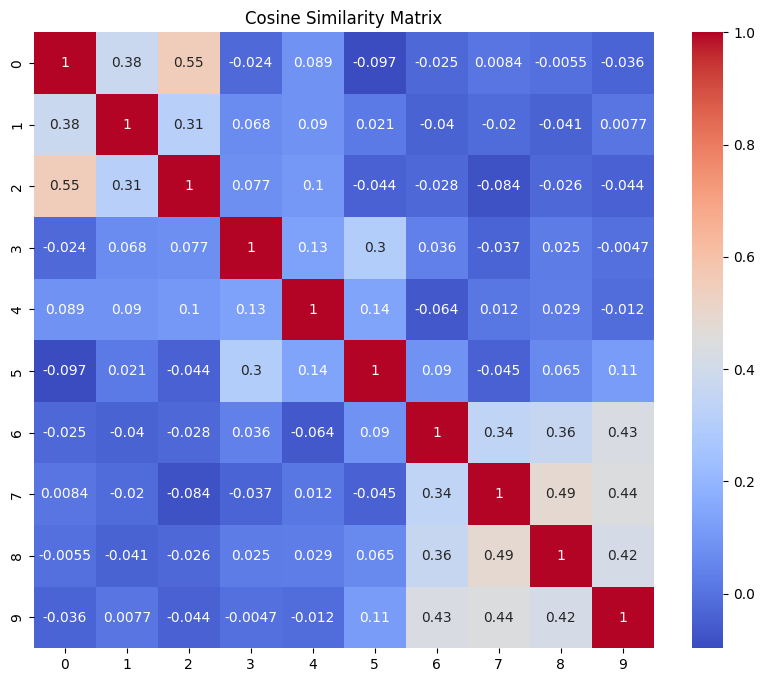

In [21]:
plt.figure(figsize=(10, 8))
sns.heatmap(similarity_matrix, annot=True, cmap='coolwarm')
plt.title("Cosine Similarity Matrix")
plt.show()

In [22]:
query = "The bowler took three wickets in one over"

In [23]:
query_embedding = model.encode([query])

In [24]:
similarities = cosine_similarity(query_embedding, embeddings)[0]

In [25]:
top_indices = np.argsort(similarities)[-2:][::-1]

for idx in top_indices:
    print("Sentence:", sentences[idx])
    print("Similarity Score:", similarities[idx])
    print("------")

Sentence: The batsman scored a century in the final match.
Similarity Score: 0.5679119
------
Sentence: The bowler delivered a fast yorker to dismiss the player.
Similarity Score: 0.5102544
------


In [26]:
import nbformat

# Read current notebook
nb = nbformat.read("embeddings_demo.ipynb", as_version=4)

# Remove widgets metadata
if "widgets" in nb["metadata"]:
    del nb["metadata"]["widgets"]

# Save cleaned notebook
nbformat.write(nb, "clean_embeddings_demo.ipynb")

print("Clean notebook created!")

ModuleNotFoundError: No module named 'nbformat'